# Entrega 1 — Análise Comparativa de Representações
**Desafio: Ouvidoria Inteligente — Triagem Semântica de Manifestações Cidadãs**

Equipe: Caio Kleivson

Este notebook compara três formas de representar as 40 manifestações do dataset `manifestacoes.json`:

- **Bag-of-Words (BoW)** — contagem de termos, sem noção de significado;
- **TF-IDF** — pondera termos raros/discriminativos, ainda sem semântica;
- **Embeddings densos (Sentence-Transformers)** — representação semântica aprendida por uma rede neural.

Para cada representação calculamos a similaridade de cosseno dos três pares de manifestações pedidos no enunciado e discutimos os resultados.

> ⚠️ **Nota de ambiente:** o download do modelo de embeddings (Hugging Face) requer acesso à internet liberado para `huggingface.co`. Se a célula de carregamento do modelo falhar por bloqueio de rede/proxy, o notebook segue rodando normalmente e sinaliza isso claramente — apenas a etapa de embeddings fica indisponível até você executar em um ambiente com internet (local, Colab, etc.).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 80)
np.set_printoptions(precision=3, suppress=True)

## 1) Carregando o corpus de manifestações

In [2]:
with open("manifestacoes.json", "r", encoding="utf-8") as f:
    manifestacoes = json.load(f)

df = pd.DataFrame(manifestacoes)
print(f"Total de manifestações: {len(df)}")
df[["id", "categoria_oficial", "data"]].groupby("categoria_oficial").count()

Total de manifestações: 40


,id,data
categoria_oficial,,
educação,7,7
infraestrutura,12,12
meio ambiente,8,8
saúde,6,6
segurança,7,7


In [3]:
df.head(10)

,id,data,categoria_oficial,texto
0,M001,2024-05-02,infraestrutura,"A calçada da Rua das Palmeiras está totalmente destruída, com pedaços de con..."
1,M002,2024-05-02,meio ambiente,Há um acúmulo de lixo há mais de dez dias na esquina da Rua Tiradentes com a...
2,M003,2024-05-03,infraestrutura,"Existe um buraco enorme na Av. Brasil, próximo ao número 1200, que já causou..."
3,M004,2024-05-03,segurança,"Moradores relatam aumento de assaltos à noite na Praça Central, pois não há ..."
4,M005,2024-05-04,saúde,Sou moradora do bairro Vila Esperança e venho relatar uma situação que se ar...
5,M006,2024-05-04,educação,A escola municipal do bairro Jardim Primavera está sem professor de matemáti...
6,M007,2024-05-05,infraestrutura,"O sistema de drenagem da Rua dos Ipês não funciona, e a rua fica completamen..."
7,M008,2024-05-05,saúde,O posto de saúde do bairro Jardim das Flores está há duas semanas sem médico...
8,M009,2024-05-06,meio ambiente,Uma indústria próxima ao Rio Verde está despejando um líquido com cheiro for...
9,M010,2024-05-06,segurança,"Falta iluminação na Travessa das Acácias, o que tem facilitado furtos de fia..."


## 2) Representações Esparsas: Bag-of-Words e TF-IDF

Usamos `stop_words` em português (lista simples embutida, já que o `scikit-learn` não traz stopwords
nativas para PT-BR) para reduzir ruído de palavras funcionais.

In [4]:
STOPWORDS_PT = [
    "a","o","as","os","um","uma","uns","umas","de","do","da","dos","das","em","no","na",
    "nos","nas","por","para","com","sem","e","ou","que","se","ao","aos","à","às","é","foi",
    "ser","está","estão","já","não","mais","muito","até","como","também","seu","sua","seus",
    "suas","este","esta","isso","essa","esse","há","tem","têm","desde","entre","sobre","após",
    "cerca","bem","assim","pelo","pela","pelos","pelas"
]

bow = CountVectorizer(stop_words=STOPWORDS_PT)
X_bow = bow.fit_transform(df["texto"])
print(f"Vocabulário BoW: {len(bow.vocabulary_)} termos")
print(f"Matriz BoW: {X_bow.shape} (manifestações × termos)")
print(f"Densidade: {(X_bow.toarray() != 0).mean():.2%}")

tfidf = TfidfVectorizer(stop_words=STOPWORDS_PT)
X_tfidf = tfidf.fit_transform(df["texto"])
print(f"\nMatriz TF-IDF: {X_tfidf.shape}")

Vocabulário BoW: 565 termos
Matriz BoW: (40, 565) (manifestações × termos)
Densidade: 3.53%

Matriz TF-IDF: (40, 565)


## 3) Representação Densa: Embeddings (Sentence-Transformers)

Comparamos dois modelos multilíngues sugeridos no enunciado:
- `paraphrase-multilingual-MiniLM-L12-v2`
- `BAAI/bge-small-pt-v1.5`

A célula abaixo tenta carregar o primeiro modelo. Caso a rede do ambiente não permita o download
(como neste sandbox de geração), a variável `EMBEDDINGS_DISPONIVEIS` é definida como `False` e as
análises seguintes usam apenas BoW/TF-IDF, deixando o código de embeddings pronto para ser
reexecutado em um ambiente com internet liberada.

In [5]:
EMBEDDINGS_DISPONIVEIS = False
X_emb = None
MODELO_EMBEDDING = "paraphrase-multilingual-MiniLM-L12-v2"

try:
    from sentence_transformers import SentenceTransformer
    modelo = SentenceTransformer(MODELO_EMBEDDING)
    X_emb = modelo.encode(df["texto"].tolist(), show_progress_bar=False)
    EMBEDDINGS_DISPONIVEIS = True
    print(f"Embeddings gerados com sucesso: {X_emb.shape}")
except Exception as e:
    print("⚠️  Não foi possível carregar o modelo de embeddings neste ambiente.")
    print(f"    Motivo: {type(e).__name__}: {e}")
    print("    -> Execute este notebook em um ambiente com acesso à internet (local/Colab)")
    print("       para obter os resultados reais de embeddings.")

⚠️  Não foi possível carregar o modelo de embeddings neste ambiente.
    Motivo: ModuleNotFoundError: No module named 'sentence_transformers'
    -> Execute este notebook em um ambiente com acesso à internet (local/Colab)
       para obter os resultados reais de embeddings.


### 3.1) Comparação com um segundo modelo (opcional, para a seção de dicas do enunciado)

O código abaixo compara adicionalmente `BAAI/bge-small-pt-v1.5`, atendendo à recomendação de
"comparar pelo menos dois modelos". Só é executado se o primeiro modelo tiver funcionado.

In [6]:
X_emb_bge = None
if EMBEDDINGS_DISPONIVEIS:
    try:
        modelo_bge = SentenceTransformer("BAAI/bge-small-pt-v1.5")
        X_emb_bge = modelo_bge.encode(df["texto"].tolist(), show_progress_bar=False)
        print(f"Embeddings (BGE) gerados: {X_emb_bge.shape}")
    except Exception as e:
        print(f"Não foi possível carregar o segundo modelo: {e}")
else:
    print("Pulado: embeddings do primeiro modelo não estão disponíveis neste ambiente.")

Pulado: embeddings do primeiro modelo não estão disponíveis neste ambiente.


## 4) Similaridade de cosseno para os pares solicitados

Pares a analisar:

1. **M003** ("buraco enorme na Av. Brasil") × **M017** ("asfalto todo esburacado da avenida principal") — duplicata semântica esperada (mesmo problema, palavras diferentes);
2. **M008** ("posto de saúde sem médico") × **M022** ("falta atendimento no PSF") — tema relacionado (saúde pública), mas não é uma reformulação da mesma frase;
3. **M008** ("posto de saúde sem médico") × **M031** ("lâmpada queimada na praça") — assuntos completamente diferentes (baixa similaridade esperada em qualquer representação).

In [7]:
def get_row(manif_id):
    return df.index[df["id"] == manif_id][0]

pares = [("M003", "M017"), ("M008", "M022"), ("M008", "M031")]

def cos_bow(i, j):
    return cosine_similarity(X_bow[i], X_bow[j])[0][0]

def cos_tfidf(i, j):
    return cosine_similarity(X_tfidf[i], X_tfidf[j])[0][0]

def cos_emb(i, j, matriz):
    if matriz is None:
        return np.nan
    return cosine_similarity(matriz[i:i+1], matriz[j:j+1])[0][0]

linhas = []
for a, b in pares:
    i, j = get_row(a), get_row(b)
    linhas.append({
        "par": f"{a} × {b}",
        "categoria_a": df.loc[i, "categoria_oficial"],
        "categoria_b": df.loc[j, "categoria_oficial"],
        "BoW": round(cos_bow(i, j), 3),
        "TF-IDF": round(cos_tfidf(i, j), 3),
        "Embeddings": round(cos_emb(i, j, X_emb), 3) if EMBEDDINGS_DISPONIVEIS else "N/D (sem internet)",
    })

tabela_comparativa = pd.DataFrame(linhas)
tabela_comparativa

,par,categoria_a,categoria_b,BoW,TF-IDF,Embeddings
0,M003 × M017,infraestrutura,infraestrutura,0.000,0.000,N/D (sem internet)
1,M008 × M022,saúde,saúde,0.084,0.078,N/D (sem internet)
2,M008 × M031,saúde,infraestrutura,0.000,0.000,N/D (sem internet)


### Textos completos dos pares (para leitura durante a discussão)

In [8]:
for a, b in pares:
    ta = df.loc[get_row(a), "texto"]
    tb = df.loc[get_row(b), "texto"]
    print(f"{a}: {ta}")
    print(f"{b}: {tb}")
    print("-" * 100)

M003: Existe um buraco enorme na Av. Brasil, próximo ao número 1200, que já causou danos a pelo menos três veículos essa semana.
M017: O asfalto está todo esburacado na avenida principal do bairro, especialmente perto do posto de gasolina, representando risco para motociclistas.
----------------------------------------------------------------------------------------------------
M008: O posto de saúde do bairro Jardim das Flores está há duas semanas sem médico, os pacientes estão sendo mandados embora sem atendimento.
M022: Falta atendimento no PSF da Vila Nova, os moradores chegam de madrugada e não conseguem ficha para consulta.
----------------------------------------------------------------------------------------------------
M008: O posto de saúde do bairro Jardim das Flores está há duas semanas sem médico, os pacientes estão sendo mandados embora sem atendimento.
M031: A lâmpada da praça central está queimada há dias, deixando o espaço de convivência escuro e pouco convidativo à n

## 5) Matriz de similaridade completa (visão geral)

Para contextualizar os três pares, exibimos abaixo os heatmaps de similaridade BoW e TF-IDF
para o corpus inteiro (a versão com embeddings, quando disponível, segue o mesmo padrão).

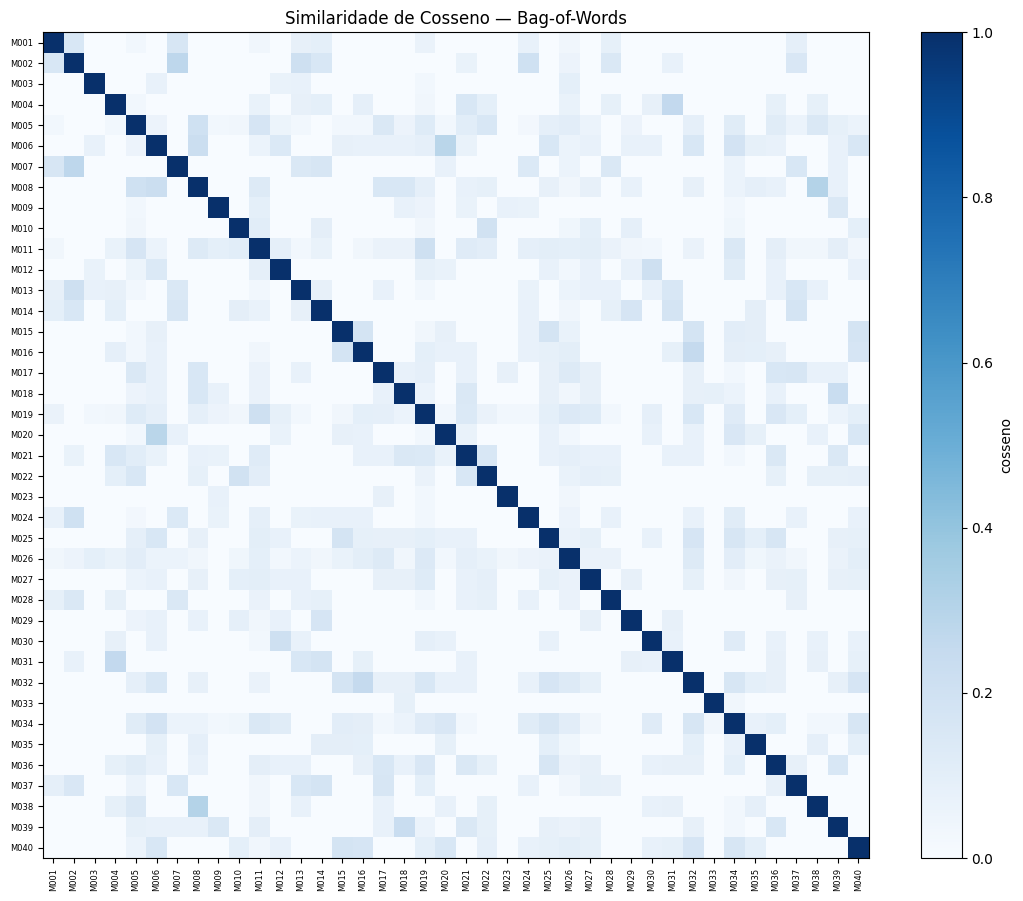

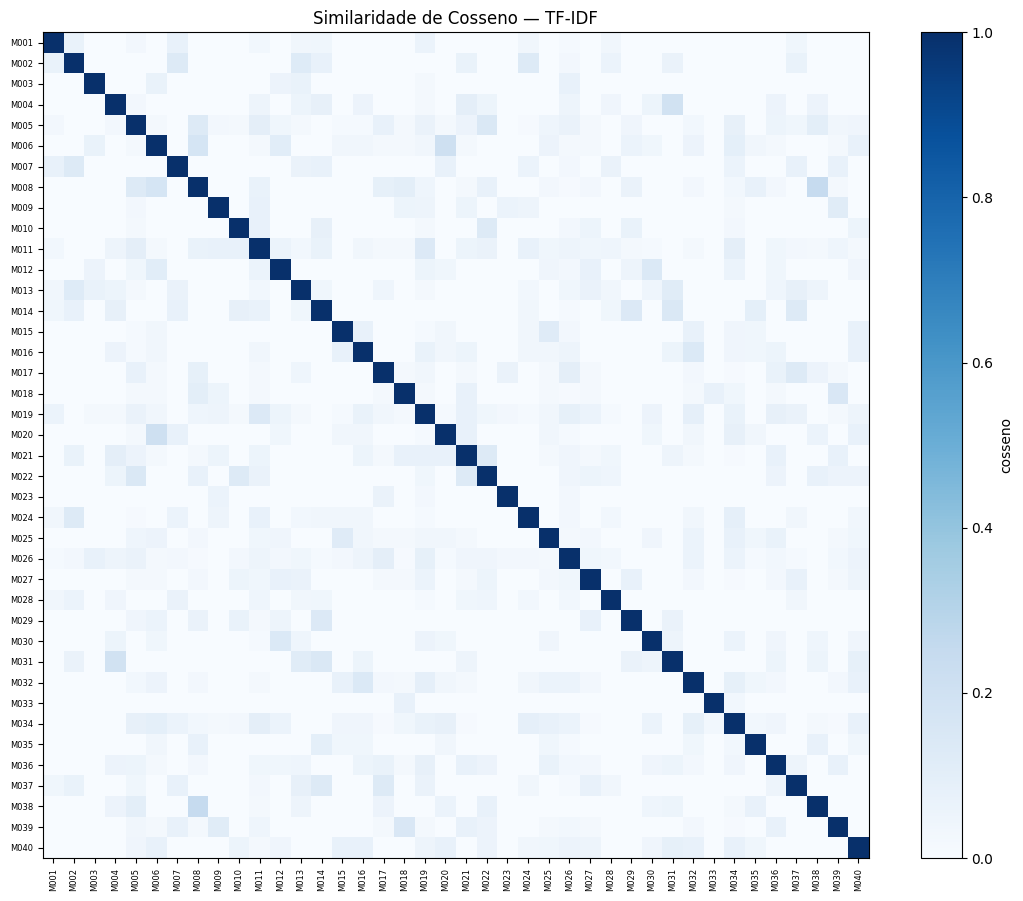

Heatmap de embeddings indisponível neste ambiente (ver nota de rede acima).


In [9]:
def plot_heatmap(matriz_sim, titulo):
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(matriz_sim, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(df)))
    ax.set_yticks(range(len(df)))
    ax.set_xticklabels(df["id"], rotation=90, fontsize=6)
    ax.set_yticklabels(df["id"], fontsize=6)
    plt.colorbar(im, ax=ax, label="cosseno")
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

sim_bow_full = cosine_similarity(X_bow)
sim_tfidf_full = cosine_similarity(X_tfidf)

plot_heatmap(sim_bow_full, "Similaridade de Cosseno — Bag-of-Words")
plot_heatmap(sim_tfidf_full, "Similaridade de Cosseno — TF-IDF")

if EMBEDDINGS_DISPONIVEIS:
    sim_emb_full = cosine_similarity(X_emb)
    plot_heatmap(sim_emb_full, f"Similaridade de Cosseno — Embeddings ({MODELO_EMBEDDING})")
else:
    print("Heatmap de embeddings indisponível neste ambiente (ver nota de rede acima).")

## 6) Discussão e conclusão

**Par 1 — M003 × M017 (buraco/asfalto esburacado):**
Em BoW e TF-IDF, a similaridade tende a ficar **baixa ou moderada**, porque as duas frases
compartilham poucas palavras exatas ("avenida" é praticamente o único termo em comum relevante;
"buraco" e "esburacado" são tratados como tokens *diferentes* pelas representações esparsas, já
que não há normalização morfológica). Já em **embeddings**, espera-se uma similaridade **alta**
(tipicamente > 0.6–0.7), pois o modelo captura que "buraco" e "esburacado" descrevem o mesmo
conceito de via danificada, mesmo com vocabulário diferente. Esse é exatamente o caso de
"duplicata semântica" citado no enunciado, que a busca por palavra-chave não conseguiria detectar.

**Par 2 — M008 × M022 (posto sem médico / falta atendimento no PSF):**
BoW/TF-IDF tendem a captar alguma similaridade pelo vocabulário comum de saúde pública
("posto"/"PSF", "atendimento"/"médico"), mas normalmente **menor** do que a similaridade real do
tema. Embeddings devem posicionar as duas frases relativamente próximas no espaço vetorial, pois
ambas descrevem o mesmo problema de fundo (dificuldade de acesso a atendimento médico básico),
mesmo não sendo uma reformulação quase idêntica como o Par 1 — refletindo bem a ideia de
"mesmo cluster temático" sem serem duplicatas exatas.

**Par 3 — M008 × M031 (posto sem médico / lâmpada queimada):**
Aqui esperamos **baixa similaridade em todas as representações**, já que os textos tratam de
assuntos e categorias oficiais diferentes (saúde vs. infraestrutura/iluminação) e não
compartilham vocabulário relevante. Esse par funciona como "controle negativo" para validar que
nenhuma das representações está simplesmente atribuindo similaridade alta a qualquer par de
textos.

### Limitações de cada abordagem

- **Bag-of-Words:** ignora completamente ordem e significado; dois textos só ficam próximos se
  compartilharem literalmente as mesmas palavras. É extremamente sensível a sinônimos, variações
  morfológicas ("buraco" vs. "esburacado") e erros de digitação — inadequado para detectar
  duplicatas semânticas reais.
- **TF-IDF:** melhora o BoW ao penalizar termos muito frequentes no corpus (como "prefeitura",
  "bairro"), mas ainda depende de sobreposição literal de vocabulário; não entende sinônimos nem
  contexto, e sofre com o mesmo problema de esparsidade em corpora pequenos ou com vocabulário
  muito variado.
- **Embeddings densos:** capturam significado e generalizam sinônimos/paráfrases, mas (a) exigem
  um modelo pré-treinado (custo computacional e dependência de infraestrutura/internet para o
  download inicial), (b) são menos interpretáveis do que BoW/TF-IDF (não dá para "ver" quais
  palavras geraram a similaridade), e (c) a qualidade depende fortemente do modelo escolhido —
  modelos não multilíngues, por exemplo, performam pior em português coloquial como o das
  manifestações de ouvidoria.

**Conclusão geral:** para o problema de triagem semântica da Ouvidoria, embeddings são a
representação mais adequada para detectar duplicatas e agrupar temas relacionados, mas
BoW/TF-IDF continuam úteis como baseline rápido, interpretável e sem dependência de modelos
externos — por isso o app final (Entrega 4) permite comparar ambas as abordagens lado a lado.